In [ ]:
from google.colab import files
files.upload()

Saving Message_Data_Spam (1).csv to Message_Data_Spam (1) (1).csv


{'Message_Data_Spam (1) (1).csv': b'v1,v2\r\nham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."\r\nham,Ok lar... Joking wif u oni...\r\nspam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C\'s apply 08452810075over18\'s\r\nham,U dun say so early hor... U c already then say...\r\nham,"Nah I don\'t think he goes to usf, he lives around here though"\r\nspam,"FreeMsg Hey there darling it\'s been 3 week\'s now and no word back! I\'d like some fun you up for it still? Tb ok! XxX std chgs to send, \xe5\xa31.50 to rcv"\r\nham,Even my brother is not like to speak with me. They treat me like aids patent.\r\nham,As per your request \'Melle Melle (Oru Minnaminunginte Nurungu Vettam)\' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune\r\nspam,WINNER!! As a valued network customer you have been selected to receivea \

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn import datasets, linear_model, metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score

In [ ]:
data = pd.read_csv('Message_Data_Spam (1).csv', encoding='cp1252')

In [ ]:
data.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   v1      5572 non-null   object
 1   v2      5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [ ]:
data.describe(include='all')

,v1,v2
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [ ]:
data.isnull().sum()

,0
v1,0
v2,0


In [ ]:
data.duplicated().sum()

np.int64(403)

In [ ]:
data.rename(columns={'v1':'spam', 'v2':'Message'}, inplace=True)

In [ ]:
data

,spam,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [ ]:
data['spam'] = pd.get_dummies(data['spam'], drop_first=True)

In [ ]:
data

,spam,Message
0,False,"Go until jurong point, crazy.. Available only ..."
1,False,Ok lar... Joking wif u oni...
2,True,Free entry in 2 a wkly comp to win FA Cup fina...
3,False,U dun say so early hor... U c already then say...
4,False,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,True,This is the 2nd time we have tried 2 contact u...
5568,False,Will Ì_ b going to esplanade fr home?
5569,False,"Pity, * was in mood for that. So...any other s..."
5570,False,The guy did some bitching but I acted like i'd...


In [ ]:
data['spam'].isnull().sum()

np.int64(0)

In [ ]:
data[data.duplicated()].spam.value_counts()
#Counts how many duplicate rows belong to each class

# It includes first one occurence also
# df[df.duplicated(keep=False)].spam.value_counts()

,count
spam,
False,309
True,94


In [ ]:
data['spam'].value_counts() #counts how many times each unique value appears in the spam column

# %age distribution
# data['spam'].value_counts(normalize=True)

,count
spam,
False,4825
True,747


In [ ]:
data.drop_duplicates(inplace=True)

In [ ]:
data.describe(include='all')

,spam,Message
count,5169,5169
unique,2,5169
top,False,Rofl. Its true to its name
freq,4516,1


In [ ]:
data['length'] = data['Message'].str.len()
data

,spam,Message,length
0,False,"Go until jurong point, crazy.. Available only ...",111
1,False,Ok lar... Joking wif u oni...,29
2,True,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,False,U dun say so early hor... U c already then say...,49
4,False,"Nah I don't think he goes to usf, he lives aro...",61
...,...,...,...
5567,True,This is the 2nd time we have tried 2 contact u...,161
5568,False,Will Ì_ b going to esplanade fr home?,37
5569,False,"Pity, * was in mood for that. So...any other s...",57
5570,False,The guy did some bitching but I acted like i'd...,125


<Axes: xlabel='length', ylabel='Count'>

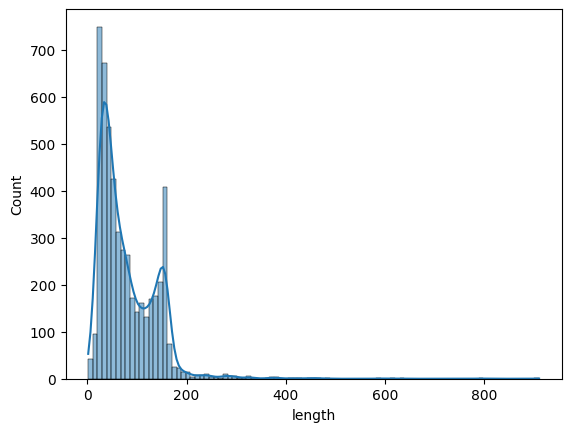

In [ ]:
sns.histplot(data['length'], kde=True)

<Axes: xlabel='length', ylabel='Density'>

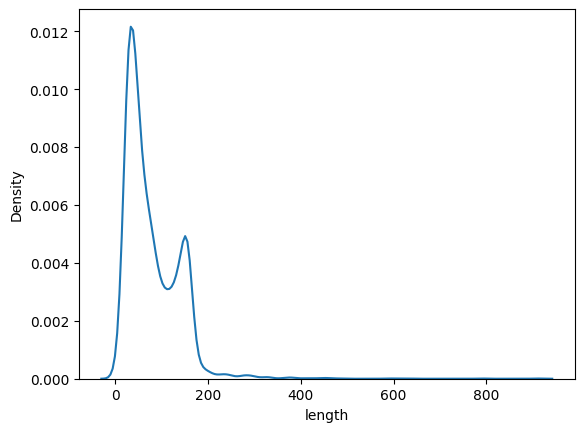

In [ ]:
sns.kdeplot(data['length'])

array([[<Axes: title={'center': 'length'}>]], dtype=object)

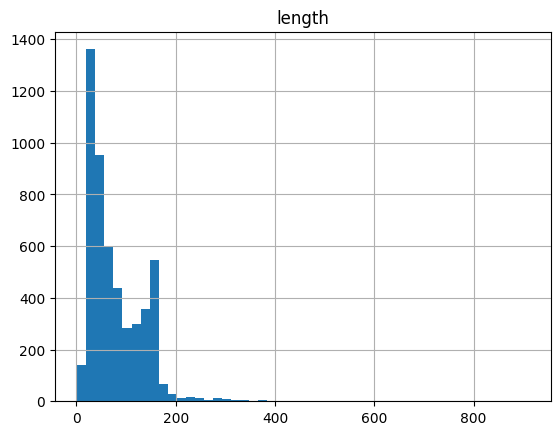

In [ ]:
data.hist(column = 'length', bins=50)

array([<Axes: title={'center': 'False'}>,
       <Axes: title={'center': 'True'}>], dtype=object)

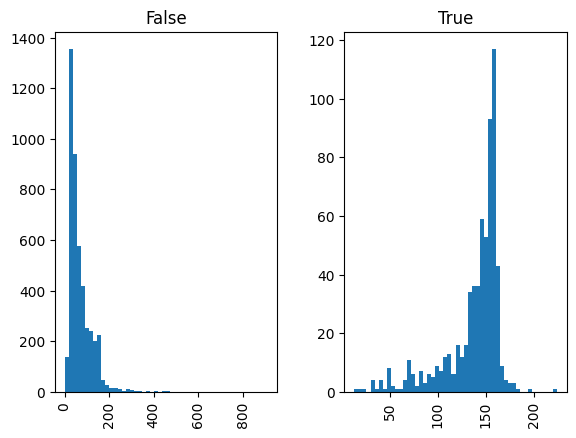

In [ ]:
data.hist(column ='length', bins=50, by='spam')

<Axes: xlabel='length', ylabel='Count'>

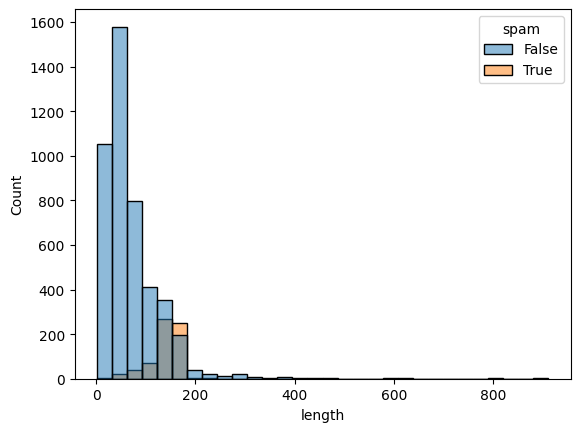

In [ ]:
sns.histplot(data=data, x='length', hue='spam', bins=30)

In [ ]:
data

,spam,Message,length
0,False,"Go until jurong point, crazy.. Available only ...",111
1,False,Ok lar... Joking wif u oni...,29
2,True,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,False,U dun say so early hor... U c already then say...,49
4,False,"Nah I don't think he goes to usf, he lives aro...",61
...,...,...,...
5567,True,This is the 2nd time we have tried 2 contact u...,161
5568,False,Will Ì_ b going to esplanade fr home?,37
5569,False,"Pity, * was in mood for that. So...any other s...",57
5570,False,The guy did some bitching but I acted like i'd...,125


In [ ]:
data['word_count'] = data['Message'].apply(lambda x : len(x.split()))
data

,spam,Message,length,word_count
0,False,"Go until jurong point, crazy.. Available only ...",111,20
1,False,Ok lar... Joking wif u oni...,29,6
2,True,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,False,U dun say so early hor... U c already then say...,49,11
4,False,"Nah I don't think he goes to usf, he lives aro...",61,13
...,...,...,...,...
5567,True,This is the 2nd time we have tried 2 contact u...,161,30
5568,False,Will Ì_ b going to esplanade fr home?,37,8
5569,False,"Pity, * was in mood for that. So...any other s...",57,10
5570,False,The guy did some bitching but I acted like i'd...,125,26


In [ ]:
# For removing stopwords
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

data['clean_word_count'] = data['Message'].apply(
    lambda x: len([word for word in x.lower().split() if word not in stop_words])
)
data

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,spam,Message,length,word_count,clean_word_count
0,False,"Go until jurong point, crazy.. Available only ...",111,20,16
1,False,Ok lar... Joking wif u oni...,29,6,6
2,True,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,23
3,False,U dun say so early hor... U c already then say...,49,11,9
4,False,"Nah I don't think he goes to usf, he lives aro...",61,13,7
...,...,...,...,...,...
5567,True,This is the 2nd time we have tried 2 contact u...,161,30,20
5568,False,Will Ì_ b going to esplanade fr home?,37,8,6
5569,False,"Pity, * was in mood for that. So...any other s...",57,10,6
5570,False,The guy did some bitching but I acted like i'd...,125,26,13


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')
X = tfidf.fit_transform(data['Message'])

array([<Axes: title={'center': 'False'}>,
       <Axes: title={'center': 'True'}>], dtype=object)

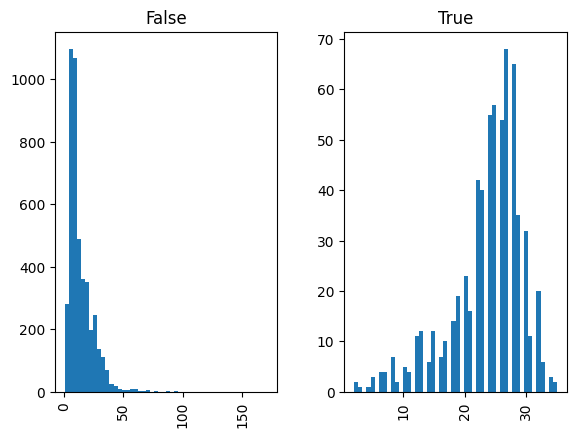

In [ ]:
data.hist(column = 'word_count', bins=50, by='spam')

In [ ]:
  #For only describing spam ones
data[data['spam']==1]['word_count'].describe()

,word_count
count,653.000000
mean,23.681470
std,5.967672
min,2.000000
25%,22.000000
50%,25.000000
75%,28.000000
max,35.000000


In [ ]:
# Describes of both spam and non-spam
data.groupby('spam')['word_count'].describe()

,count,mean,std,min,25%,50%,75%,max
spam,,,,,,,,
False,4516.0,14.134632,11.116240,1.0,7.0,11.0,18.0,171.0
True,653.0,23.681470,5.967672,2.0,22.0,25.0,28.0,35.0


In [ ]:
data.iloc[25,1]    # data.iloc[row_index, column_index]

"Just forced myself to eat a slice. I'm really not hungry tho. This sucks. Mark is getting worried. He knows I'm sick when I turn down pizza. Lol"

In [ ]:
data.loc[25, 'Message']

"Just forced myself to eat a slice. I'm really not hungry tho. This sucks. Mark is getting worried. He knows I'm sick when I turn down pizza. Lol"

<Axes: xlabel='spam', ylabel='word_count'>

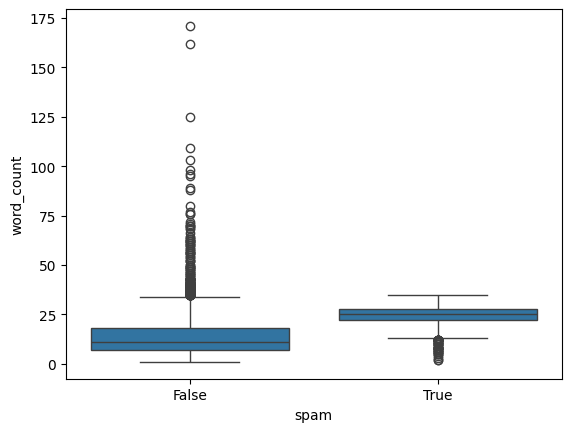

In [ ]:
import seaborn as sns
sns.boxplot(x='spam', y='word_count', data=data)

NORMALIZATION

In [ ]:
data['Message'] = data['Message'].str.lower()

In [ ]:
import re  # re It helps you: Search text, Clean text, Remove unwanted patterns, Extract specific patterns

In [ ]:
text = "Win money now!!! Call 9876543210"
clean_text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

print(clean_text)

Win money now Call 9876543210


In [ ]:
s = 'Should i call his boss and tell him, knowing this may get him fired?'.lower()
s = re.sub(r'[^a-zA-Z0-9\s]', '', s)
s

'should i call his boss and tell him knowing this may get him fired'

In [ ]:
data['Message'] = data['Message'].apply(lambda x : re.sub(r"[^a-z0-9\s]", "",x))
data['Message']

,Message
0,go until jurong point crazy available only in ...
1,ok lar joking wif u oni
2,free entry in 2 a wkly comp to win fa cup fina...
3,u dun say so early hor u c already then say
4,nah i dont think he goes to usf he lives aroun...
...,...
5567,this is the 2nd time we have tried 2 contact u...
5568,will b going to esplanade fr home
5569,pity was in mood for that soany other suggest...
5570,the guy did some bitching but i acted like id ...


Stopwords Removal

In [ ]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
sw = set(stopwords.words('english'))
s = 'This is the 2nd Time We have Tried 2 Contact u'
s_new = ''
for i in s.lower().split():
    if i not in sw:
        s_new = ' '.join([i for i in s.lower().split() if i not in sw])
s_new

'2nd time tried 2 contact u'

In [ ]:
data['Message'] = data['Message'].apply(lambda x : ' '.join([i for i in str(x).split() if i not in sw]))
data.reset_index(inplace=True, drop=True)
data

,spam,Message,length,word_count,clean_word_count
0,False,go jurong point crazy available bugis n great ...,111,20,16
1,False,ok lar joking wif u oni,29,6,6
2,True,free entry 2 wkly comp win fa cup final tkts 2...,155,28,23
3,False,u dun say early hor u c already say,49,11,9
4,False,nah dont think goes usf lives around though,61,13,7
...,...,...,...,...,...
5164,True,2nd time tried 2 contact u u 750 pound prize 2...,161,30,20
5165,False,b going esplanade fr home,37,8,6
5166,False,pity mood soany suggestions,57,10,6
5167,False,guy bitching acted like id interested buying s...,125,26,13


In [ ]:
data.iloc[569,1]

'mobile number 5000 claim calls us back ring claims hot line 09050005321'

In [ ]:
data.iloc[555]

,555
spam,False
Message,fuck babe miss already know cant let send mone...
length,146
word_count,34
clean_word_count,20


In [ ]:
data.iloc[5164]

,5164
spam,True
Message,2nd time tried 2 contact u u 750 pound prize 2...
length,161
word_count,30
clean_word_count,20


In [ ]:
Master_word_list = ' '.join(data['Message']).split()
unique_word_count = {}

In [ ]:
# for i in set(Master_word_list):
#     unique_word_count[i] = Master_word_list.count(i)
# unique_word_count

In [ ]:
from collections import Counter            #unique_word_count.most_common(10) for top10 count
unique_word_count = Counter(Master_word_list)
unique_word_count

Counter({'go': 269,
         'jurong': 1,
         'point': 13,
         'crazy': 15,
         'available': 14,
         'bugis': 7,
         'n': 125,
         'great': 103,
         'world': 24,
         'la': 7,
         'e': 81,
         'buffet': 2,
         'cine': 7,
         'got': 231,
         'amore': 1,
         'wat': 92,
         'ok': 251,
         'lar': 38,
         'joking': 6,
         'wif': 27,
         'u': 1001,
         'oni': 4,
         'free': 243,
         'entry': 21,
         '2': 443,
         'wkly': 9,
         'comp': 9,
         'win': 54,
         'fa': 2,
         'cup': 6,
         'final': 15,
         'tkts': 2,
         '21st': 2,
         'may': 41,
         '2005': 2,
         'text': 170,
         '87121': 2,
         'receive': 32,
         'questionstd': 1,
         'txt': 139,
         'ratetcs': 1,
         'apply': 26,
         '08452810075over18s': 1,
         'dun': 55,
         'say': 82,
         'early': 33,
         'hor': 2,
     

In [ ]:
term_freq = pd.Series(Counter(Master_word_list)).sort_values(ascending=False)
term_freq

,0
u,1001
call,487
im,456
2,443
get,364
...,...
cribbs,1
spiritual,1
barring,1
sudden,1


<Axes: >

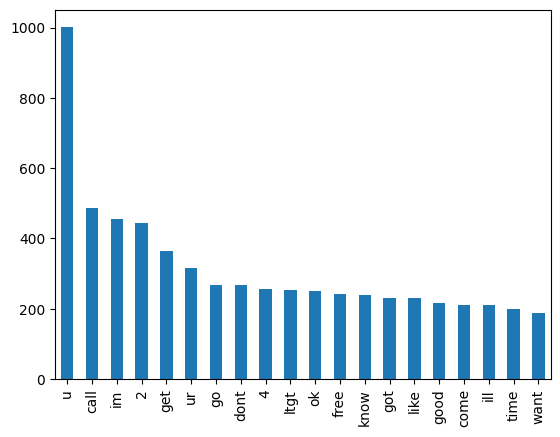

In [ ]:
term_freq.head(20).plot(kind='bar')

In [ ]:
least_freq_word_used = term_freq[term_freq<=1].index
term_freq[term_freq<=2].index

Index(['2p', 'tkts', '21st', 'buffet', 'talks', 'probs', 'paperwork',
       'privacy', 'violated', 'prepayment',
       ...
       'desk', 'childporn', 'jumpers', 'hat', 'belt', 'cribbs', 'spiritual',
       'barring', 'sudden', 'influx'],
      dtype='object', length=6905)

In [ ]:
data

,spam,Message,length,word_count,clean_word_count
0,False,go jurong point crazy available bugis n great ...,111,20,16
1,False,ok lar joking wif u oni,29,6,6
2,True,free entry 2 wkly comp win fa cup final tkts 2...,155,28,23
3,False,u dun say early hor u c already say,49,11,9
4,False,nah dont think goes usf lives around though,61,13,7
...,...,...,...,...,...
5164,True,2nd time tried 2 contact u u 750 pound prize 2...,161,30,20
5165,False,b going esplanade fr home,37,8,6
5166,False,pity mood soany suggestions,57,10,6
5167,False,guy bitching acted like id interested buying s...,125,26,13


In [ ]:
data['Message'] = data['Message'].apply(lambda x :' '.join(i for i in x.split() if i not in least_freq_word_used))
data['Message']

,Message
0,go point crazy available bugis n great world l...
1,ok lar joking wif u oni
2,free entry 2 wkly comp win fa cup final tkts 2...
3,u dun say early hor u c already say
4,nah dont think goes usf lives around though
...,...
5164,2nd time tried 2 contact u u 750 pound prize 2...
5165,b going esplanade fr home
5166,mood
5167,guy acted like id interested buying something ...


In [ ]:
most_freq_used_words = term_freq.head(9).index

In [ ]:
data['Message'] = data['Message'].apply(lambda x :' '.join(i for i in x.split() if i not in most_freq_used_words))
data['Message']

,Message
0,point crazy available bugis n great world la e...
1,ok lar joking wif oni
2,free entry wkly comp win fa cup final tkts 21s...
3,dun say early hor c already say
4,nah think goes usf lives around though
...,...
5164,2nd time tried contact 750 pound prize claim e...
5165,b going esplanade fr home
5166,mood
5167,guy acted like id interested buying something ...


Stemming

In [ ]:
from nltk.stem import PorterStemmer
st = PorterStemmer()
st.stem('buying')

'buy'

In [ ]:
data['Message'].apply(lambda x : ' '.join(st.stem(i) for i in x.split()))


,Message
0,point crazi avail bugi n great world la e buff...
1,ok lar joke wif oni
2,free entri wkli comp win fa cup final tkt 21st...
3,dun say earli hor c alreadi say
4,nah think goe usf live around though
...,...
5164,2nd time tri contact 750 pound prize claim eas...
5165,b go esplanad fr home
5166,mood
5167,guy act like id interest buy someth els next w...


Lemmatization

In [ ]:
from nltk.stem import WordNetLemmatizer
nltk.download('omw-1.4')
nltk.download('wordnet')

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
lem = WordNetLemmatizer()

In [ ]:
[lem.lemmatize(i, pos='v') for i in ['write', 'Bought', 'writing', 'played']]

['write', 'Bought', 'write', 'play']

In [ ]:
data['Message'] = data['Message'].apply(lambda x : ' '.join(lem.lemmatize(i, pos='v') for i in x.split()))
data['Message']

,Message
0,point crazy available bugis n great world la e...
1,ok lar joke wif oni
2,free entry wkly comp win fa cup final tkts 21s...
3,dun say early hor c already say
4,nah think go usf live around though
...,...
5164,2nd time try contact 750 pound prize claim eas...
5165,b go esplanade fr home
5166,mood
5167,guy act like id interest buy something else ne...


Count-Vectorizer

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()

In [ ]:
X = cv.fit_transform(data['Message'])
X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 35348 stored elements and shape (5169, 3206)>

In [ ]:
X_df = pd.DataFrame(
    X.toarray(),
    columns=cv.get_feature_names_out()
)
X_df

,008704050406,020603,0207,02073162414,020903,021,050703,0578,071104,07123456789,...,youve,yr,yrs,yummy,yun,yunny,yuo,yup,zed,zoe
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5164,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5165,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5166,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5167,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
y = data['spam']

In [ ]:
x = data['Message']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=10)
x_train_cv = cv.fit_transform(x_train)
x_test_cv = cv.transform(x_test)
x_train_cv

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 24719 stored elements and shape (3618, 3056)>

Classification Models - Logistic, decision Tree, Random forest, Naive Bayes

In [ ]:
from sklearn.linear_model import LogisticRegression
logR = LogisticRegression()
logR.fit(x_train_cv, y_train)
logR.predict(x_test_cv)

array([False, False, False, ..., False, False, False])

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_auc_score

In [ ]:
print(accuracy_score(y_test, logR.predict(x_test_cv)))

0.9677627337201805


In [ ]:
print(roc_auc_score(y_test, logR.predict(x_test_cv)))

0.8789394249462805


In [ ]:
from sklearn.metrics import confusion_matrix
df_cv = pd.DataFrame(confusion_matrix(y_test, logR.predict(x_test_cv)), columns = ['predict_0', 'predict_1'], index = ['actual_0','actual_1'])
df_cv

,predict_0,predict_1
actual_0,1347,1
actual_1,49,154


<Axes: >

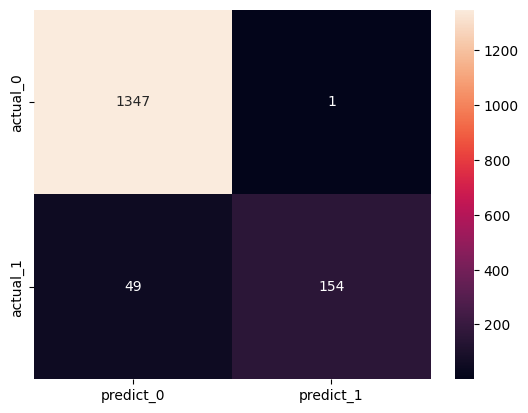

In [ ]:
sns.heatmap(df_cv, annot = True, fmt='g')

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, logR.predict(x_test_cv)))

              precision    recall  f1-score   support

       False       0.96      1.00      0.98      1348
        True       0.99      0.76      0.86       203

    accuracy                           0.97      1551
   macro avg       0.98      0.88      0.92      1551
weighted avg       0.97      0.97      0.97      1551



In [ ]:
feature_names = cv.get_feature_names_out()
feature_names

array(['008704050406', '020603', '0207', ..., 'yunny', 'yup', 'zed'],
      dtype=object)